## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 1 - Notebook 2A - From ImageClassification - Train / Test
## Flavia Leaf Dataset and Flowers Dataset
---

## Importing the Required Libraries
---

In [1]:
import os

import numpy as np
from sklearn import model_selection, neighbors, metrics, preprocessing

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Dataset Loading 

In [2]:
# Select the dataset
dataset_name = 'flavia' # ['flavia', 'flowers']

In [3]:
# Load the feature dataset
if dataset_name == 'flavia':
    features_df = pd.read_csv("flavia_features.csv")
elif dataset_name == 'flowers':
    features_df = pd.read_csv("flowers_features.csv")

# Get the feature names
features = [col for col in features_df.columns if col not in ['filename', 'label']]
class_names = sorted(features_df['label'].unique())

# Create the feature matrix and label vector
X = features_df[features].to_numpy()
y = features_df['label'].to_numpy()

print(f"Features: {features}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: ['area', 'major_axis', 'minor_axis', 'solidity', 'eccentricity']
X shape: (191, 5)
y shape: (191,)


## Hold-out Validation
---

In [4]:
# Split the dataset into 'feature_mat_ok' based on 'label_list'.
# 30% of the images are allocated to the test set.
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    test_size=0.3, 
    stratify=y,
    random_state=42
)

# Normalization (Feature Scaling)
---

Here we will scale the features, implementing StandardScale from scratch, for didactics.

In the future, we will use the feature.StandardScaler class from scikit-learn

In [5]:
# Mean of the features in the training set
X_train_mean = X_train.mean(0)
# Standard deviation of the features in the training set
X_train_std = X_train.std(0)

# Normal feature transform (Standard Scaler)
X_train_norm = (X_train - X_train_mean) / X_train_std
X_test_norm = (X_test - X_train_mean) / X_train_std

In [6]:
stats = pd.DataFrame({
    'Mean (before)': X_train.mean(axis=0),
    'Std (before)': X_train.std(axis=0),
    'Mean (after)': X_train_norm.mean(axis=0),
    'Std (after)': X_train_norm.std(axis=0)
}, index=features)

display(stats.round(4))


stats_test = pd.DataFrame({
    'Mean': X_test_norm.mean(axis=0),
    'Std': X_test_norm.std(axis=0)
}, index=features)

display(stats_test.round(4))

,Mean (before),Std (before),Mean (after),Std (after)
area,42243.3233,11958.7316,-0.0,1.0
major_axis,290.1190,64.1187,-0.0,1.0
minor_axis,203.0155,44.8628,-0.0,1.0
solidity,0.8340,0.2049,-0.0,1.0
eccentricity,0.5586,0.2674,0.0,1.0


,Mean,Std
area,0.0263,0.9828
major_axis,0.0136,0.9716
minor_axis,-0.0000,0.9994
solidity,0.0322,0.9658
eccentricity,0.0725,0.9283


* Note that the normalized test features do not have exactly zero mean and unit standard deviation because the  `Standard Scaler` is fitted on the training set only.

In [7]:
df = pd.DataFrame(X_train_norm, columns=features)
df['class'] = y_train

display(df)

,area,major_axis,minor_axis,solidity,eccentricity,class
0,0.101823,1.266593,-1.182362,0.650154,1.332386,aesculus_chinensis
1,-0.074366,1.111175,-1.249416,0.690425,1.327723,aesculus_chinensis
2,-0.896861,0.706111,-1.841042,0.656068,1.401601,aesculus_chinensis
3,-0.866758,0.616879,-1.750225,0.572949,1.374053,aesculus_chinensis
4,-0.739570,-0.576947,0.287552,-1.475631,-0.137063,acer_palmatum
...,...,...,...,...,...,...
128,0.687922,1.606842,-0.853551,0.699257,1.306876,aesculus_chinensis
129,0.790609,-0.286845,0.974680,0.639035,-0.522504,cersis_chinensis
130,1.097832,-0.178465,1.181082,0.659502,-0.611339,cersis_chinensis
131,1.151516,-0.250659,1.399302,0.685702,-1.177989,cersis_chinensis


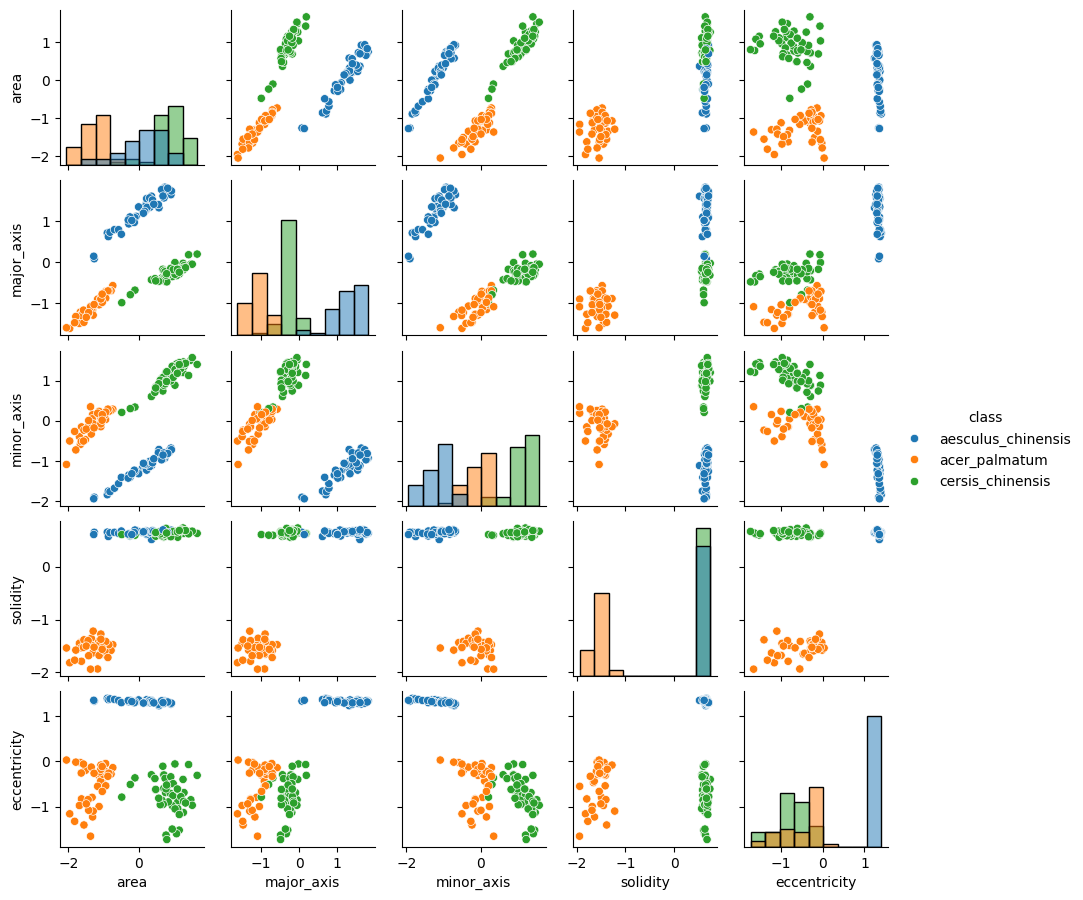

In [8]:
if dataset_name == 'flavia':
    g = sns.PairGrid(df, hue='class', vars=features)
    g.fig.set_size_inches(9, 9)
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot)
    g.add_legend()
    # sns.move_legend(g, "lower center", bbox_to_anchor=(0.5, -0.05), ncol=len(class_names))

else: # 'flowers'
    print("Feature visualization is not adequate for the 'flowers' dataset due to a large number of features.")

# Feature Selection

We select the features based sonely in the training set samples. 

In [9]:
if dataset_name == 'flavia':
    # Features
    ### selected_features = [0, 1] # area, major_axis - ** Easy **
    ### selected_features = [1, 4] # major_axis, eccentricity - ** Medium **
    selected_features = [0, 3] # area, solidity - ** Hard **

    # Select only two features for visualization  
    X_train_norm = X_train_norm[:,selected_features]
    X_test_norm = X_test_norm[:,selected_features]

else: # 'flowers'
    # We will not apply feature selection for the 'flowers' dataset.
    print("We will not apply feature selection for the 'flowers' dataset.")

print(f"Shape of the training data: {X_train_norm.shape}")
print(f"Shape of the test data: {X_test_norm.shape}")

Shape of the training data: (133, 2)
Shape of the test data: (58, 2)


## Classifying using K-Nearest Neighbors  
---  

In [10]:
# Build a K-NN classifier with k = 3
clf = neighbors.KNeighborsClassifier(n_neighbors=3)

# Train the classifier
clf.fit(X_train_norm, y_train)

# Test the classifier
pred = clf.predict(X_test_norm)

## Model Evaluation
---

The classifier performance is evaluated on the test set by comparing the predicted and true class labels. 

The confusion matrix and classification metrics are used to summarize the results.

In [11]:
# Compare predicted and true labels
correct = y_test == pred

results = pd.DataFrame({
    'True class': y_test,
    'Predicted class': pred,
    'Correct': y_test == pred
})

display(results)

,True class,Predicted class,Correct
0,cersis_chinensis,cersis_chinensis,True
1,cersis_chinensis,cersis_chinensis,True
2,acer_palmatum,acer_palmatum,True
3,cersis_chinensis,cersis_chinensis,True
4,aesculus_chinensis,aesculus_chinensis,True
5,acer_palmatum,acer_palmatum,True
6,cersis_chinensis,cersis_chinensis,True
7,acer_palmatum,acer_palmatum,True
8,acer_palmatum,acer_palmatum,True
9,aesculus_chinensis,aesculus_chinensis,True


In [12]:
# Count correct and incorrect predictions
n_correct = correct.sum()
n_incorrect = (~correct).sum()

print(f'Correct predictions:   {n_correct}')
print(f'Incorrect predictions: {n_incorrect}')

Correct predictions:   48
Incorrect predictions: 10



Confusion matrix:
[[17  0  0]
 [ 0 14  5]
 [ 0  5 17]]

Confusion matrix visualization:


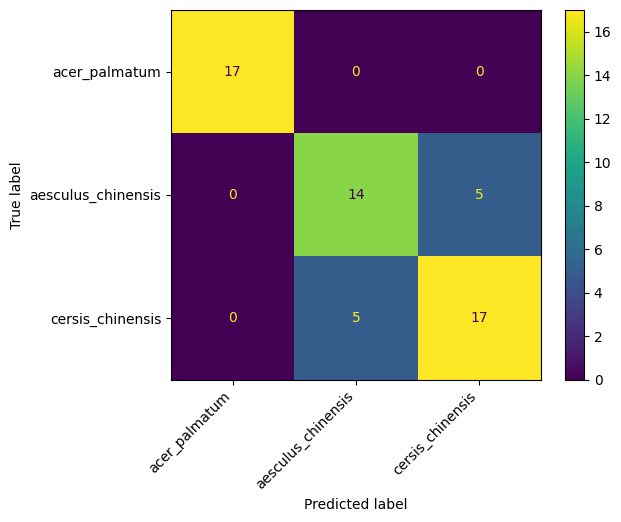

In [13]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred))


# Confusion matrix visualization
print('\nConfusion matrix visualization:')
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=class_names
)
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
print('\nClassification report:')
print(metrics.classification_report(y_test, pred))


Classification report:
                    precision    recall  f1-score   support

     acer_palmatum       1.00      1.00      1.00        17
aesculus_chinensis       0.74      0.74      0.74        19
  cersis_chinensis       0.77      0.77      0.77        22

          accuracy                           0.83        58
         macro avg       0.84      0.84      0.84        58
      weighted avg       0.83      0.83      0.83        58



## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---

* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* Scikit-image documentation.
    - https://scikit-image.org/docs/stable/
* scikit-learn - User Guide.
    * https://scikit-learn.org/stable/user_guide.html
    
**Flavia Leaf Dataset:**
* WU, S.G.;  BAO, F.S; XU, E.Y.; WANG, Y.-X.; CHANG, Y.-F.; XIANG, Q.-L. A Leaf Recognition Algorithm for Plant classification Using Probabilistic Neural Network. IEEE 7th International Symposium on Signal Processing and Information Technology, Dec. 2007, Cairo, Egypt.
    - https://doi.org/10.1109/ISSPIT.2007.4458016 
    - Flavia Leaf Dataset: https://flavia.sourceforge.net/  
